# Check the Ec against Z of the MC for new corrections

In [ ]:
!source /gluster/data/next/software/IC_john/confic_ic.sh

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import tables as tb
from matplotlib import colors

from typing          import Optional
from typing          import Union
from typing          import Callable

from concurrent.futures import ProcessPoolExecutor

import sys,os,os.path
from pathlib import Path
sys.path.append("/gluster/data/next/software/IC_311024/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
sys.path.append("/gluster/data/next/notebooks/")
os.environ['ICTDIR']='/gluster/data/next/software/IC_311024/'

from invisible_cities.io.dst_io           import load_dst, load_dsts, df_writer
from invisible_cities.io.hits_io          import hits_writer
from invisible_cities.core                import tbl_functions   as tbl
from invisible_cities.core.core_functions import in_range
#from invisible_cities.cities.beersheba    import hitc_to_df_
from invisible_cities.io.hits_io          import hits_from_df
from invisible_cities.evm.nh5             import HitsTable
from invisible_cities.types.symbols       import NormStrategy
from invisible_cities.types.ic_types      import NoneType
from invisible_cities.reco.corrections    import read_maps, get_df_to_z_converter, apply_all_correction
from invisible_cities.evm.event_model     import HitCollection

from tqdm import tqdm


from john_books.year_of_horse_notebooks.MC_validator import functions_HE as func

In [2]:
import traceback

def load_single_file(file_path):
    '''
    Load data from a single h5 file and produce dataframes for /Tracking/Tracks

    Args:
        file_path       :       str
                                Path to the h5 file to be loaded.

    Returns:
        tracks_df       :       pandas.DataFrame
                                DataFrame containing the /Tracking/Tracks data.
        failed          :       int
                                1 if the file failed to load, 0 otherwise.
    '''
    try: 
        tracks_df = load_dst(file_path, 'RECO', 'Events')
        return tracks_df, 0
    except Exception as e:
        print(f'File {file_path} broke with error:\n{e}')
        x = pd.DataFrame()
        return x, 1

def load_data_fast(folder_path):
    '''
    Load multiple h5 files and produce concatenated dataframes for /Tracking/Tracks, /MC/Particles, and their corresponding eventmap.

    Args:
        folder_path     :       str
                                Path to the folder containing the h5 files.

    Returns:
        tracks          :       pandas.DataFrame
                                Concatenated DataFrame containing the /Tracking/Tracks data from all h5 files.
        total_failures  :       int
                                Total number of failed file loads.
    '''
    try:
        file_names = [f for f in os.listdir(folder_path) if f.endswith('.h5')]
        file_paths = [os.path.join(folder_path, f) for f in file_names][:500]

        with ProcessPoolExecutor() as executor:
            results = list(executor.map(load_single_file, file_paths))

        # Separate the results into respective lists
        tracks_list, failures = zip(*results)

        tracks = pd.concat(tracks_list, axis=0, ignore_index=True)

        # Sum up the failures
        total_failures = sum(failures)

        return tracks, total_failures
    except Exception as e:
        print(f"An error occurred: {e}")
        traceback.print_exc()


# Load it in

In [3]:
n100_dir = '/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602/sophronia/'

holder, err = load_data_fast(n100_dir)

File /gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602/sophronia/NEXT100_Tl208_Port1a_DEP_sophronia_6313.h5 broke with error:
HDF5 error back trace

  File "H5F.c", line 836, in H5Fopen
    unable to synchronously open file
  File "H5F.c", line 796, in H5F__open_api_common
    unable to open file
  File "H5VLcallback.c", line 3863, in H5VL_file_open
    open failed
  File "H5VLcallback.c", line 3675, in H5VL__file_open
    open failed
  File "H5VLnative_file.c", line 128, in H5VL__native_file_open
    unable to open file
  File "H5Fint.c", line 1965, in H5F_open
    unable to read superblock
  File "H5Fsuper.c", line 614, in H5F__super_read
    truncated file: eof = 4133195, sblock->base_addr = 0, stored_eof = 5700724

End of HDF5 error back trace

Unable to open/create file '/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602/sophronia/NEXT100_Tl208_Port1a_DEP_sophronia_6313.h5'


In [4]:
display(holder)

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,200.775,0.0,0.0,684.050006,6.318841,2278.197812,-1.0,0.010018,-1,-1.0
1,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,185.225,0.0,0.0,687.411795,5.043478,1033.666385,-1.0,0.004505,-1,-1.0
2,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,216.325,0.0,0.0,687.411795,6.028986,1235.647233,-1.0,0.005467,-1,-1.0
3,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,185.225,0.0,0.0,690.803544,5.681159,645.776844,-1.0,0.002815,-1,-1.0
4,12400000,2.480000e+13,0,187.775247,260.502887,1,353.575,185.225,0.0,0.0,690.803544,6.376811,724.851485,-1.0,0.003272,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56819755,452900149,9.058003e+14,0,-172.320598,-303.157376,1,-190.675,-359.025,0.0,0.0,391.244709,11.652174,743.807654,-1.0,0.003271,-1,-1.0
56819756,452900149,9.058003e+14,0,-172.320598,-303.157376,1,-190.675,-343.475,0.0,0.0,391.244709,18.608694,1187.871817,-1.0,0.005134,-1,-1.0
56819757,452900149,9.058003e+14,0,-172.320598,-303.157376,1,-175.125,-359.025,0.0,0.0,391.244709,8.173913,521.775512,-1.0,0.002272,-1,-1.0
56819758,452900149,9.058003e+14,0,-172.320598,-303.157376,1,-175.125,-343.475,0.0,0.0,391.244709,6.608696,421.861045,-1.0,0.001811,-1,-1.0


## correct energy with maps - normal method

In [5]:
from correction_functions import apply_3Dmap, NormMethod

In [54]:
# load in the 3d map
map_3d = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/MC_3Dmap_median.h5'
map_3d_df = pd.read_hdf(map_3d)

In [7]:
display(map_3d_df)
print(map_3d_df.nevents.unique())

,k,i,j,nevents,mu,sigma,mu_error,sigma_error,dt,x,y
0,0,0,0,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-495.0
1,0,0,1,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-485.0
2,0,0,2,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-475.0
3,0,0,3,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-465.0
4,0,0,4,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-455.0
...,...,...,...,...,...,...,...,...,...,...,...
99995,9,99,95,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,455.0
99996,9,99,96,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,465.0
99997,9,99,97,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,475.0
99998,9,99,98,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,485.0


[ nan   3.   9.  12.  24.  41.  40.  54.  64.  57.  65.  61.  48.  21.
  20.  22.   8.   1.   4.   7.  15.  35.  36.  49.  45.  51.  53.  43.
  47.  42.  58.  25.  32.  19.  10.   2.  23.  52.  55.  39.  50.  33.
  46.  38.  27.  37.  31.   6.  16.  34.  59.  44.  62.  14.  30.  29.
  26.  28.  56.  18.  17.  60.  74.  70.   5.  81.  11.  67.  13.  66.
  63.  69.  77.  71.  68.  72.  78.  79.  85.  76.  73.  80.  82.  89.
  88.  86.  83.  75. 116.  84.  93.]


In [8]:
print(holder.columns.values)

['event' 'time' 'npeak' 'Xpeak' 'Ypeak' 'nsipm' 'X' 'Y' 'Xrms' 'Yrms' 'Z'
 'Q' 'E' 'Qc' 'Ec' 'track_id' 'Ep']


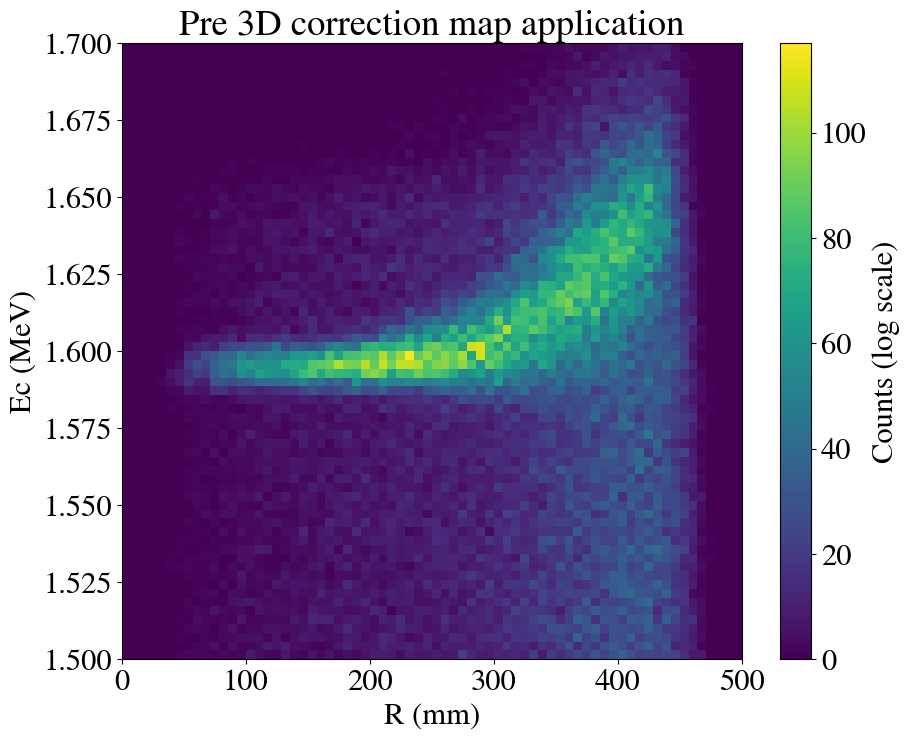

In [9]:
from matplotlib.colors import LogNorm

holder['radius'] = (holder['X']**2 + holder['Y']**2)**0.5
plt.hist2d(holder.groupby('event').radius.mean(), holder.groupby('event').Ec.sum(), 
            range=[[0, 500], [1.5, 1.7]], bins=70)
plt.xlabel('R (mm)')
plt.ylabel('Ec (MeV)')
plt.title('Pre 3D correction map application')
plt.colorbar(label='Counts (log scale)')
plt.show()

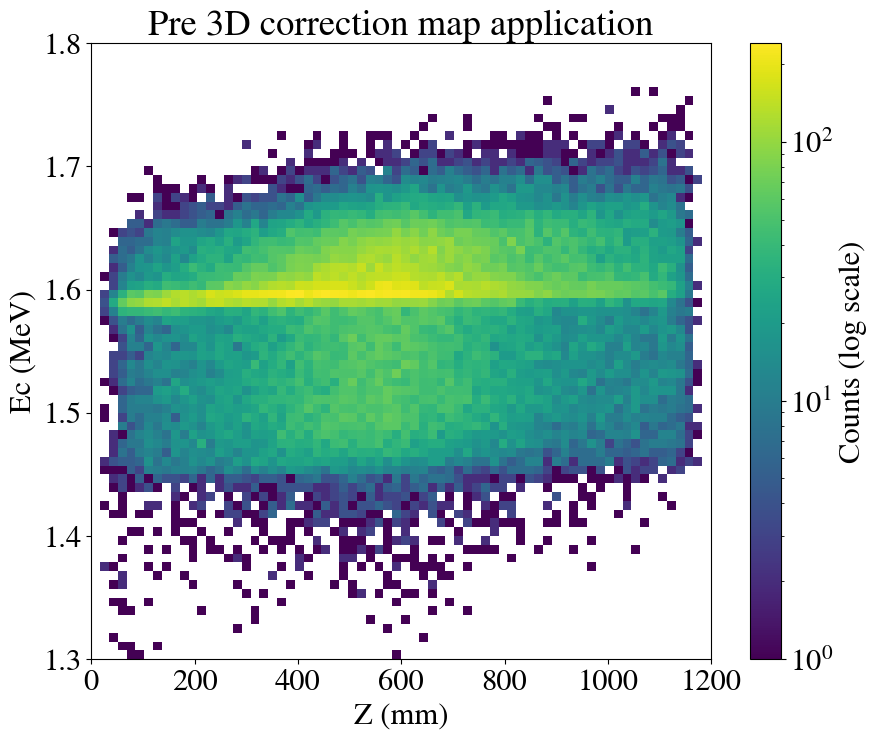

In [10]:
from matplotlib.colors import LogNorm

plt.hist2d(holder.groupby('event').Z.mean(), holder.groupby('event').Ec.sum(), 
           range=[[0, 1200], [1.3, 1.8]], bins=70, norm=LogNorm())

plt.xlabel('Z (mm)')
plt.ylabel('Ec (MeV)')
plt.title('Pre 3D correction map application')
plt.colorbar(label='Counts (log scale)')
plt.show()

## apply the map

In [11]:
holder['Ec_check'] = apply_3Dmap(map_3d_df, NormMethod.maximum, holder.Z, holder.X, holder.Y, holder.E, keV = True)

## see if the results make any sense

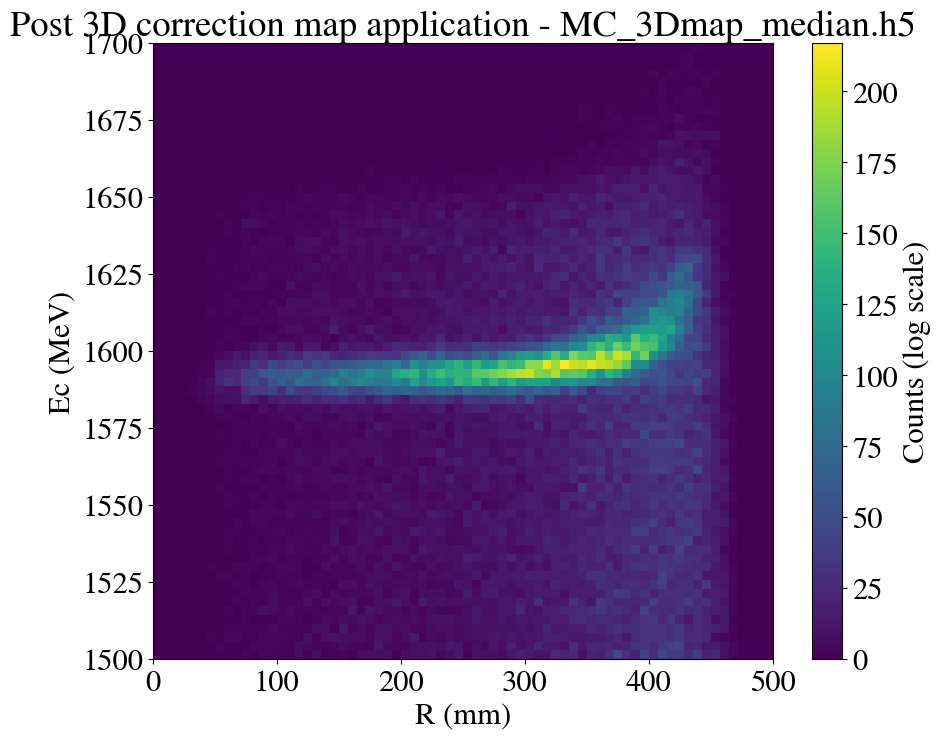

In [12]:
holder['radius'] = (holder['X']**2 + holder['Y']**2)**0.5
plt.hist2d(holder.groupby('event').radius.mean(), holder.groupby('event').Ec_check.sum(), 
           range=[[0, 500], [1500, 1700]], bins=70)
           #bins = 70)
plt.xlabel('R (mm)')
plt.ylabel('Ec (MeV)')
plt.title(f"Post 3D correction map application - {map_3d.split('/')[-1]}")
plt.colorbar(label='Counts (log scale)')
plt.show()

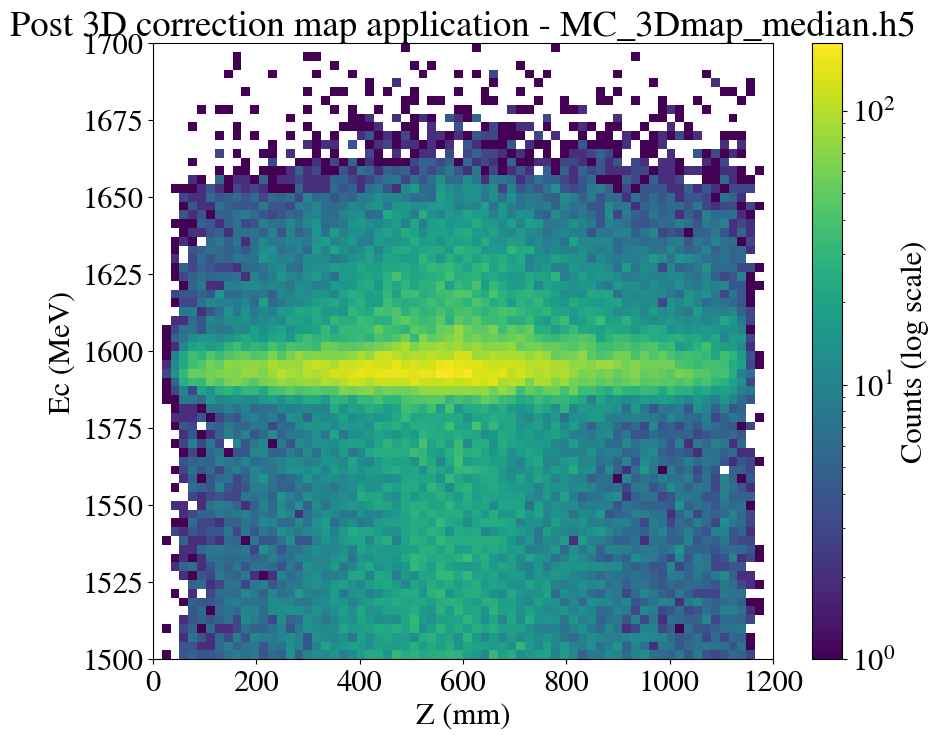

In [17]:
from matplotlib.colors import LogNorm

plt.hist2d(holder.groupby('event').Z.mean(), holder.groupby('event').Ec_check.sum(), 
           bins=70, norm=LogNorm(), range = [[0, 1200], [1500, 1700]])

plt.xlabel('Z (mm)')
plt.ylabel('Ec (MeV)')
plt.title(f"Post 3D correction map application - {map_3d.split('/')[-1]}")
plt.colorbar(label='Counts (log scale)')
plt.show()

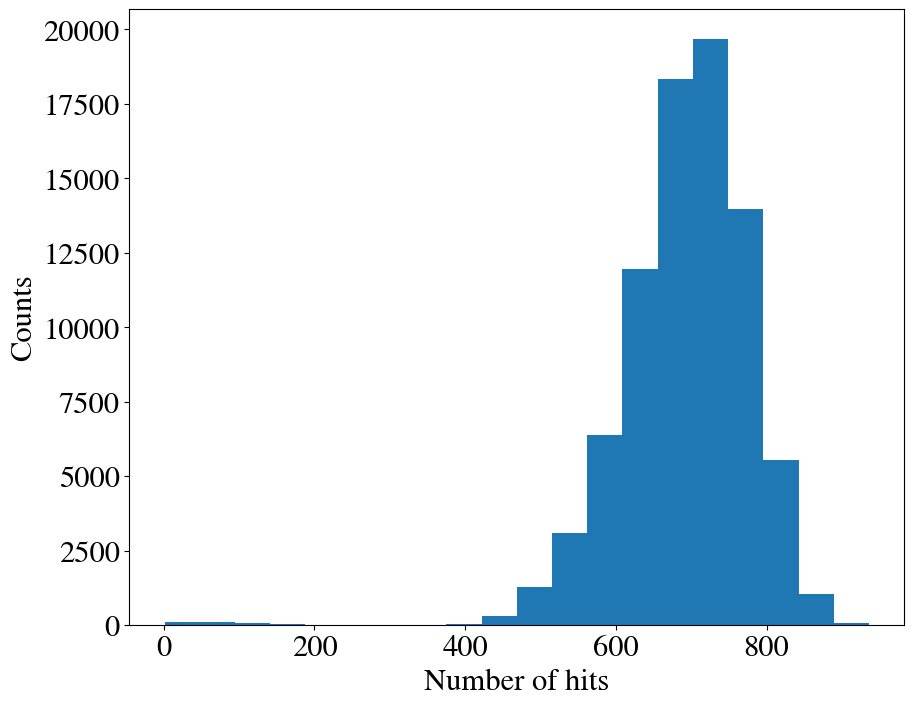

In [27]:
# number of hits per event, max hit charge.
plt.hist([len(df) for evt, df in holder.groupby('event')], bins = 20)
plt.xlabel('Number of hits')
plt.ylabel('Counts')
plt.show()

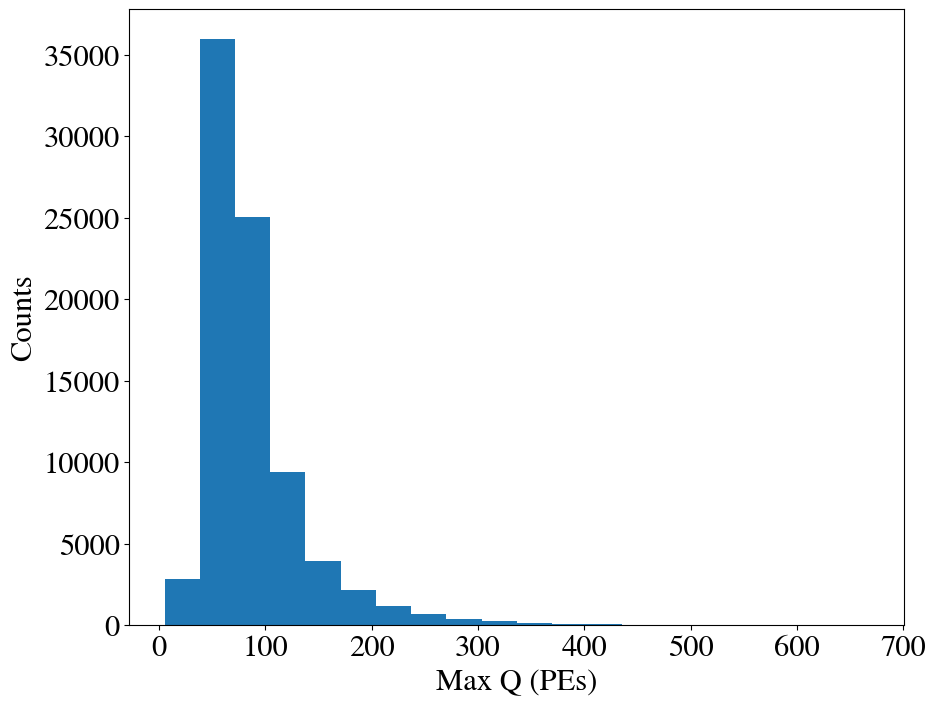

In [28]:
# max hit charge per event
plt.hist([df.Q.max() for evt, df in holder.groupby('event')], bins = 20)
plt.xlabel('Max Q (PEs)')
plt.ylabel('Counts')
plt.show()

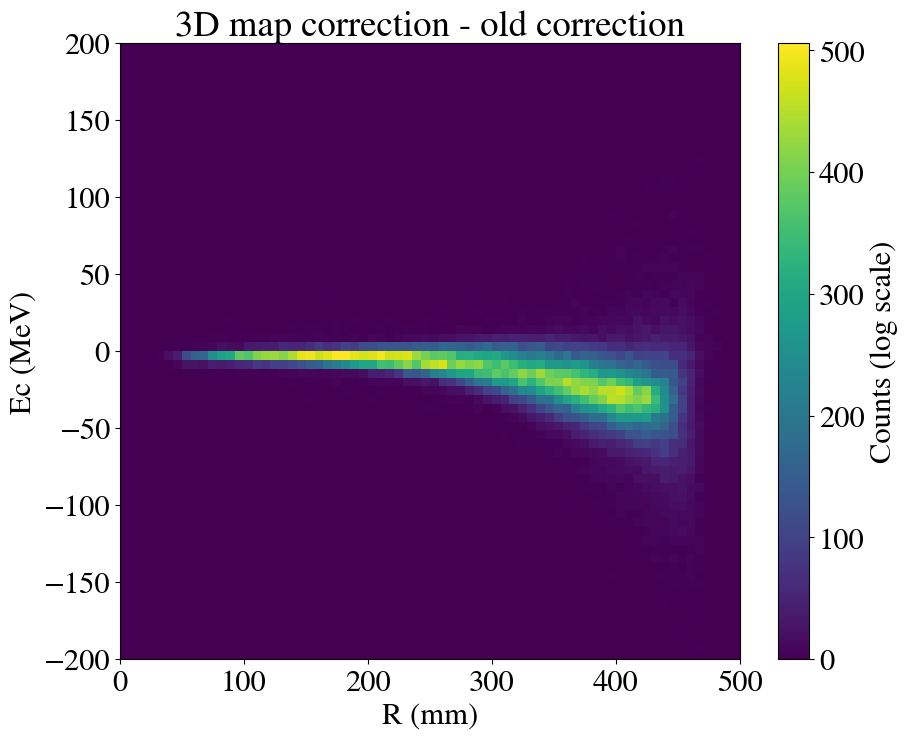

In [18]:
holder['radius'] = (holder['X']**2 + holder['Y']**2)**0.5
plt.hist2d(holder.groupby('event').radius.mean(), holder.groupby('event').Ec_check.sum() - (holder.groupby('event').Ec.sum()*1000), 
           range=[[0, 500], [-200, 200]], bins=70)
           #bins = 70)
plt.xlabel('R (mm)')
plt.ylabel('Ec (MeV)')
plt.title('3D map correction - old correction')
plt.colorbar(label='Counts (log scale)')
plt.show()

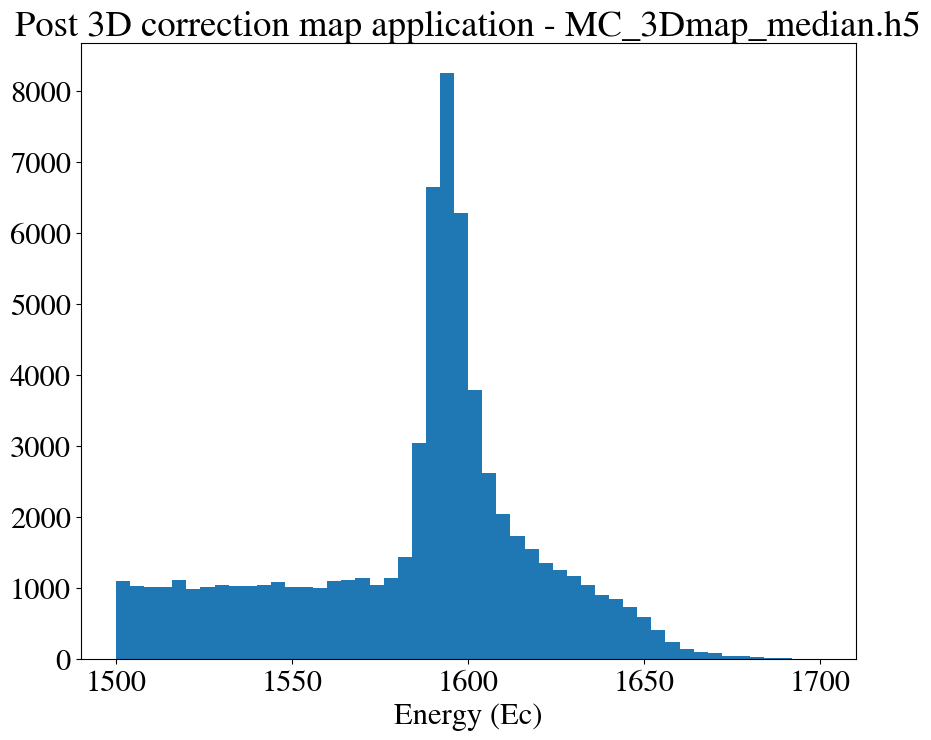

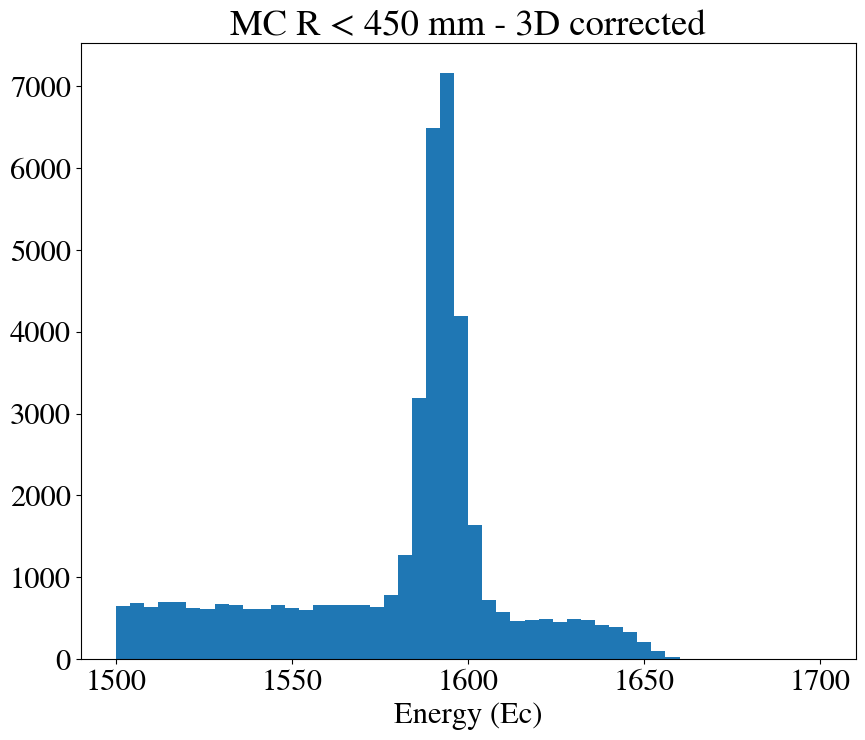

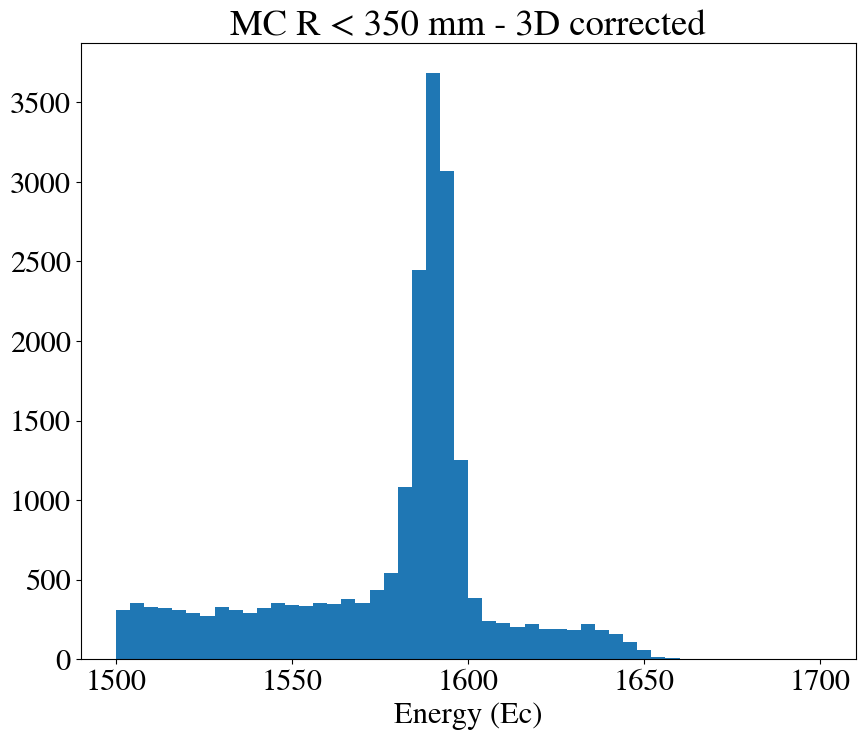

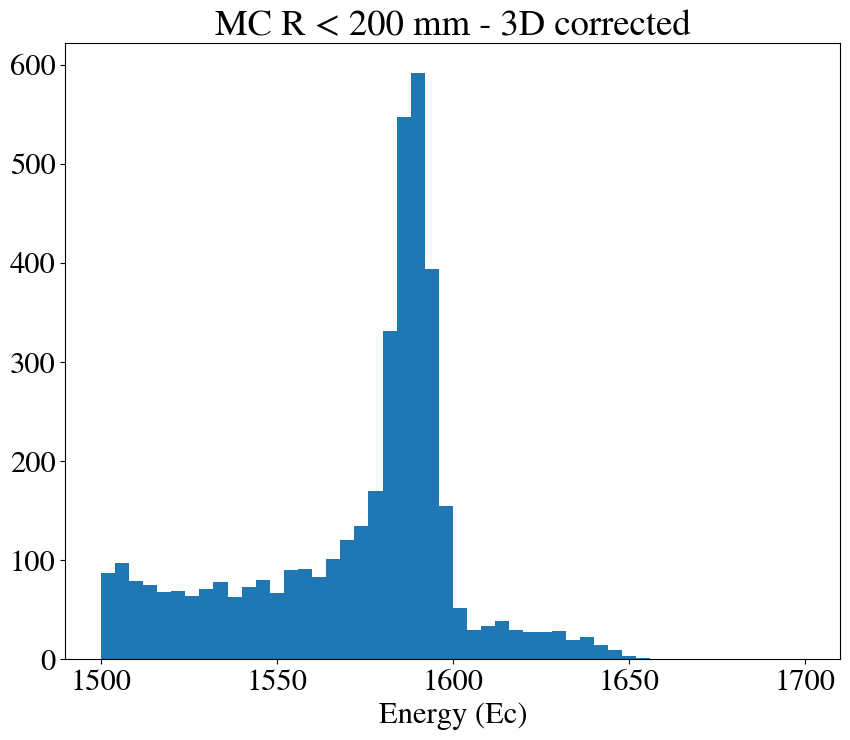

In [19]:
plt.hist(holder.groupby('event').Ec_check.sum(), bins = 50, range = (1500, 1700))
#plt.title('MC - 3D corrected')
plt.title(f"Post 3D correction map application - {map_3d.split('/')[-1]}")
plt.xlabel('Energy (Ec)')
plt.show()

range = 450
plt.hist(holder[holder['radius'] < range].groupby('event').Ec_check.sum(), bins=50, range=(1500, 1700))
plt.title(f'MC R < {range} mm - 3D corrected')
plt.xlabel('Energy (Ec)')
plt.show()

range = 350
plt.hist(holder[holder['radius'] < range].groupby('event').Ec_check.sum(), bins=50, range=(1500, 1700))
plt.title(f'MC R < {range} mm - 3D corrected')
plt.xlabel('Energy (Ec)')
plt.show()

range = 200
plt.hist(holder[holder['radius'] < range].groupby('event').Ec_check.sum(), bins=50, range=(1500, 1700))
plt.title(f'MC R < {range} mm - 3D corrected')
plt.xlabel('Energy (Ec)')
plt.show()

# r dependence wrt z position

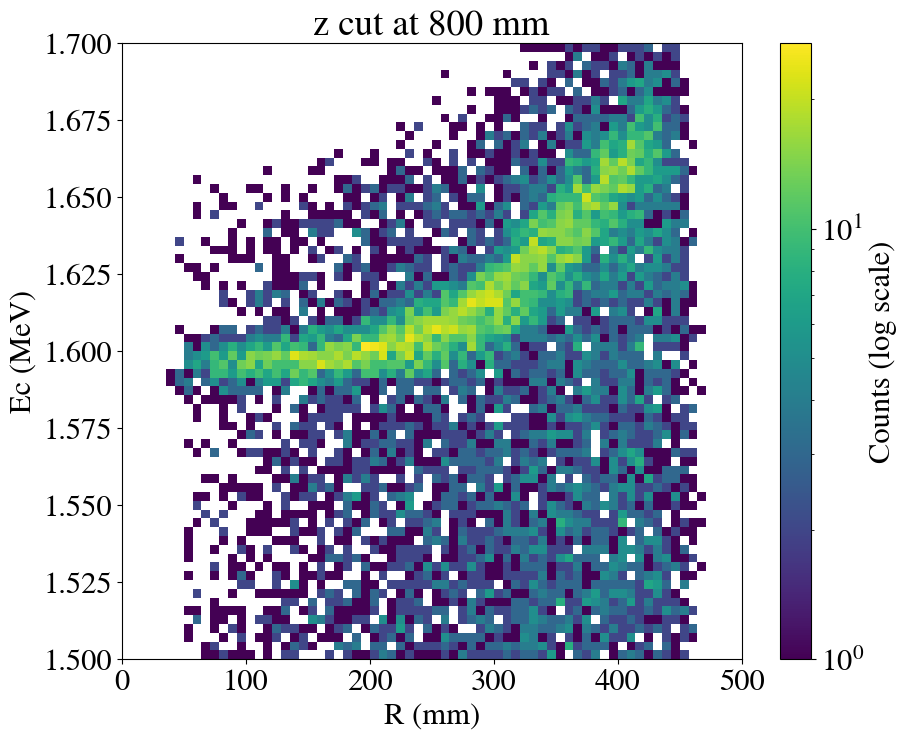

In [34]:
from matplotlib.colors import LogNorm
z_range = 800

plt.hist2d(holder[holder.Z > z_range].groupby('event').radius.mean(), holder[holder.Z > z_range].groupby('event').Ec_check.sum(), 
           range=[[0, 500], [1.5, 1.7]], bins=70, norm=LogNorm())

plt.xlabel('R (mm)')
plt.ylabel('Ec (MeV)')
plt.title(f'z cut at {z_range} mm')
plt.colorbar(label='Counts (log scale)')
plt.show()

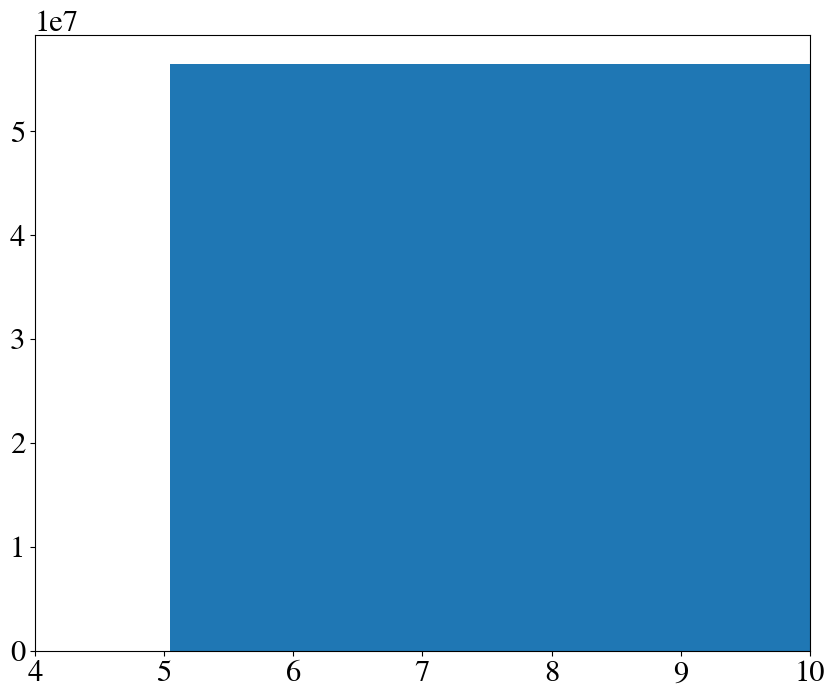

In [29]:
# sanity check, is q_thr = 5?
plt.hist(holder.Q.values)
plt.xlim([4, 10])
plt.show()
# it is

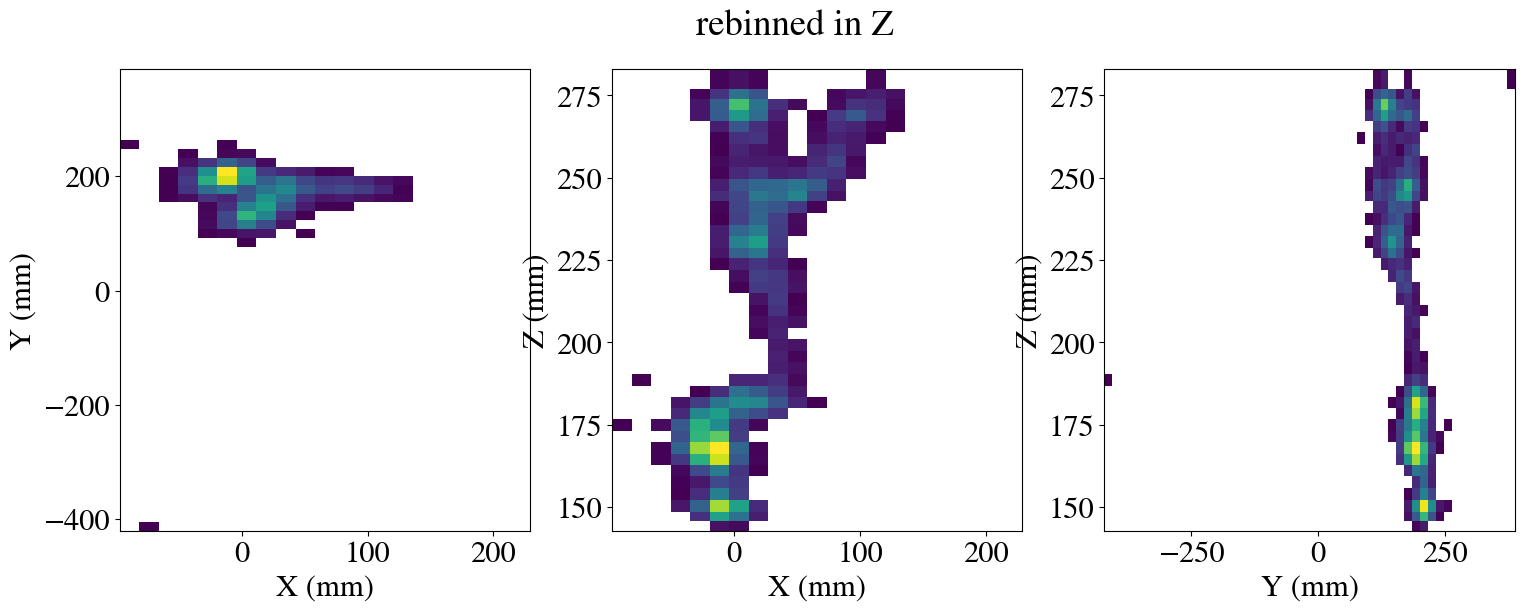

In [44]:
# sanity check, what do the tracks actually look like?
def raw_plotter(q, evt, pitch = 15.55):
    '''
    just plots the hits, nothing smart
    '''

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    xx = np.arange(q.X.min(), q.X.max() + pitch, pitch)
    yy = np.arange(q.Y.min(), q.Y.max() + pitch, pitch)
    zz = np.sort(q.Z.unique())

    axes[0].hist2d(q.X, q.Y, bins=[xx, yy], weights=q.Q, cmin=0.0001);
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q.Q, cmin=0.0001);
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');


    axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q.Q, cmin=0.0001);
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle("rebinned in Z")
    plt.show(fig)

N = 5
raw_plotter(holder[holder.event == holder.event.unique()[N]], 0)

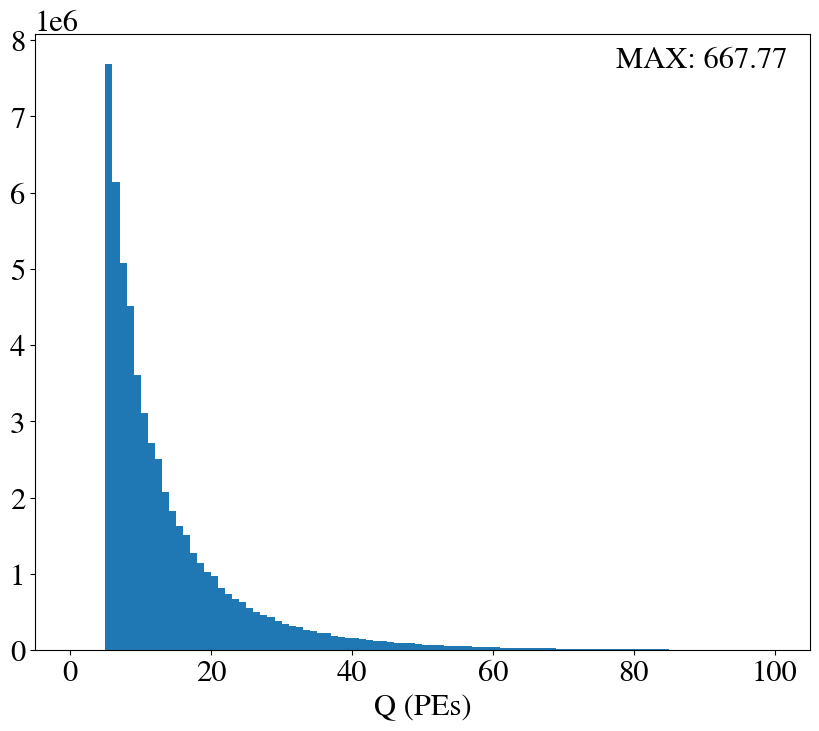

In [57]:
# hit q distribution
plt.hist(holder.Q.values, bins = 100, range = [0, 100])
plt.xlabel('Q (PEs)')
plt.text(
    0.75, 0.98,
    f"MAX: {holder.Q.max():.2f}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top")
plt.show()

### apply charge cut of 10 PE, recorrect

In [65]:
PE_cut = 10

from invisible_cities.cities.beersheba import cut_over_Q
cut_sensors = cut_over_Q(PE_cut, ['E', 'Ec'])


holder_high_q_cut = cut_sensors(holder).copy(deep = True)
display(holder_high_q_cut)

/gluster/data/next/software/miniconda/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in divide
  result = getattr(ufunc, method)(*inputs, **kwargs)


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,radius,Ec_check
0,100000,2.000018e+11,0,395.887401,36.171825,1,384.675,-32.475,0.0,0.0,46.248153,10.666666,837.485429,-1.0,0.003520,-1,-1.0,386.043367,3.104541
1,100000,2.000018e+11,0,395.887401,36.171825,1,369.125,-32.475,0.0,0.0,49.109434,13.739130,548.479660,-1.0,0.002293,-1,-1.0,370.550794,1.992774
2,100000,2.000018e+11,0,395.887401,36.171825,1,369.125,-16.925,0.0,0.0,49.109434,14.260870,569.308035,-1.0,0.002365,-1,-1.0,369.512816,2.042121
3,100000,2.000018e+11,0,395.887401,36.171825,1,384.675,-48.025,0.0,0.0,49.109434,15.826088,631.793084,-1.0,0.002679,-1,-1.0,387.661265,2.340382
4,100000,2.000018e+11,0,395.887401,36.171825,1,384.675,-32.475,0.0,0.0,49.109434,88.057968,3515.361186,-1.0,0.014778,-1,-1.0,386.043367,13.031369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29790667,999600147,1.999200e+15,0,12.736621,61.459716,1,73.675,91.925,0.0,0.0,378.152134,24.811596,1176.661871,-1.0,0.004560,-1,-1.0,117.805820,3.641953
29790668,999600147,1.999200e+15,1,-17.465029,19.171614,1,-19.625,29.725,0.0,0.0,407.397700,10.666666,3244.887821,-1.0,0.012679,-1,-1.0,35.619043,6.721728
29790669,999600147,1.999200e+15,1,-17.465029,19.171614,1,-4.075,29.725,0.0,0.0,410.672788,13.739131,1415.390147,-1.0,0.005547,-1,-1.0,30.003021,2.921097
29790670,999600147,1.999200e+15,1,-17.465029,19.171614,1,-4.075,45.275,0.0,0.0,410.672788,13.565217,1397.473723,-1.0,0.005451,-1,-1.0,45.458016,2.870523


In [66]:
# reapply map
holder_high_q_cut['Ec_check'] = apply_3Dmap(map_3d_df, NormMethod.maximum, holder_high_q_cut.Z, holder_high_q_cut.X, holder_high_q_cut.Y, holder_high_q_cut.E, keV = True)

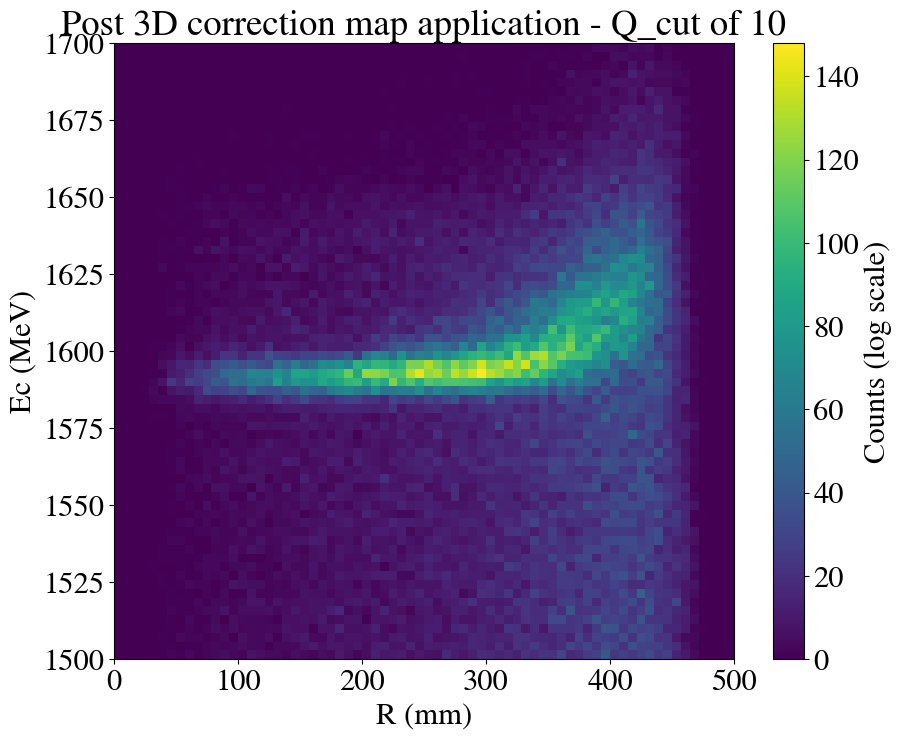

In [68]:
# plot and look
holder_high_q_cut['radius'] = (holder_high_q_cut['X']**2 + holder_high_q_cut['Y']**2)**0.5
plt.hist2d(holder_high_q_cut.groupby('event').radius.mean(), holder_high_q_cut.groupby('event').Ec_check.sum(), 
           range=[[0, 500], [1500, 1700]], bins=70)
           #bins = 70)
plt.xlabel('R (mm)')
plt.ylabel('Ec (MeV)')
plt.title(f'Post 3D correction map application - Q_cut of {PE_cut}')
plt.colorbar(label='Counts (log scale)')
plt.show()

### apply corrections gonzalos way


In [72]:
from scipy.interpolate import interp1d
from scipy.interpolate import griddata

def get_corr3d(fname):
    #krmap = pd.read_hdf(fname, "/krmap")
    krmap = pd.read_hdf(fname)
    #meta  = pd.read_hdf(fname, "/mapmeta")
    dtxy_map   = krmap.loc[:, ['dt', 'x', 'y']].values
    #krmap['factor']     = np.nanmax(krmap.e0) / krmap.e0
    #krmap['factor'] = krmap.e0.values
    krmap['factor'] = krmap.mu.values
    factor_map = krmap.factor.values
    def corr(dt, x, y, method="nearest"):
        dtxy_data   = np.stack([dt, x, y], axis=1)
        factor_data = griddata(dtxy_map, factor_map, dtxy_data, method=method)
        return factor_data
    return corr
  
def smooth(y, n=4):
    m  = len(y)
    yf = np.flip(y)
    y  = np.concatenate([yf, y, yf])
    z  = np.ones(n) / n
    y  = np.convolve(y, z, mode="same")
    return y[m:2*m]

def get_corrt(fname, n=4):
    time_data = pd.read_hdf(fname, "/data")
    smoothed  = smooth(time_data.e0, n)
    corr      = smoothed.min() / smoothed
    time_correction = interp1d(time_data.time,  corr, "cubic", bounds_error=False, fill_value=(corr[0], corr[-1]))
    return time_correction
  

# HOW TO APPLY CORRECTIONS
# map3d_filename = "/path/to/combined_15546_15557.map3d"
# corr3d = get_corr3d(map3d_filename)
# corrt  = get_corrt ( time_filename)
#
# corrected_energy = hits.E * corr3d(hits.Z, hits.X, hits.Y) * corrt(hits.time)


In [7]:
x = [1,2,3,4,5]
print(x[:3])

[1, 2, 3]


In [26]:
#display(pd.read_hdf(map3d_filename))
holder_smaller = holder[holder.event.isin(holder.event.values[:1000000])]
display(holder_smaller)

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,radius
0,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,200.775,0.0,0.0,684.050006,6.318841,2278.197812,-1.0,0.010018,-1,-1.0,393.155823
1,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,185.225,0.0,0.0,687.411795,5.043478,1033.666385,-1.0,0.004505,-1,-1.0,385.446755
2,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,216.325,0.0,0.0,687.411795,6.028986,1235.647233,-1.0,0.005467,-1,-1.0,401.319581
3,12400000,2.480000e+13,0,187.775247,260.502887,1,338.025,185.225,0.0,0.0,690.803544,5.681159,645.776844,-1.0,0.002815,-1,-1.0,385.446755
4,12400000,2.480000e+13,0,187.775247,260.502887,1,353.575,185.225,0.0,0.0,690.803544,6.376811,724.851485,-1.0,0.003272,-1,-1.0,399.153581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000136,241200159,4.824003e+14,3,-375.788622,118.148631,1,-392.825,76.375,0.0,0.0,337.317569,5.623188,190.858117,-1.0,0.000828,-1,-1.0,400.180736
1000137,241200159,4.824003e+14,3,-375.788622,118.148631,1,-392.825,91.925,0.0,0.0,337.317569,8.057971,273.497733,-1.0,0.001186,-1,-1.0,403.437339
1000138,241200159,4.824003e+14,3,-375.788622,118.148631,1,-486.125,231.875,0.0,0.0,337.317569,5.797101,196.760961,-1.0,NaN,-1,-1.0,538.594032
1000139,241200159,4.824003e+14,3,-375.788622,118.148631,1,-439.475,91.925,0.0,0.0,340.502829,5.043478,674.302323,-1.0,0.003292,-1,-1.0,448.986059


In [64]:
print(map_3d)
display(pd.read_hdf(map_3d))
display(pd.read_hdf("/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/" + "MC_202602.map3d", '/krmap'))

/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/MC_3Dmap_median.h5


,k,i,j,nevents,mu,sigma,mu_error,sigma_error,dt,x,y
0,0,0,0,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-495.0
1,0,0,1,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-485.0
2,0,0,2,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-475.0
3,0,0,3,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-465.0
4,0,0,4,NaN,NaN,NaN,NaN,NaN,86.5,-495.0,-455.0
...,...,...,...,...,...,...,...,...,...,...,...
99995,9,99,95,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,455.0
99996,9,99,96,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,465.0
99997,9,99,97,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,475.0
99998,9,99,98,NaN,NaN,NaN,NaN,NaN,1283.5,495.0,485.0


,zbin,xbin,ybin,z,x,y,e0,e0u,q0,q0u,eres,n,chi2e,chi2q,n_density
0,0,1,1,0.0,-495.0,-495.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
1,0,1,2,0.0,-495.0,-485.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
2,0,1,3,0.0,-495.0,-475.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
3,0,1,4,0.0,-495.0,-465.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
4,0,1,5,0.0,-495.0,-455.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,10,100,96,1500.0,495.0,455.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
119996,10,100,97,1500.0,495.0,465.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
119997,10,100,98,1500.0,495.0,475.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0
119998,10,100,99,1500.0,495.0,485.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0


In [73]:
#map3d_filename = "/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/" + "MC_from_LT_202602.map3d"
#map3d_filename = "/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/" + "MC_202602.map3d"
map3d_filename = map_3d

corr3d = get_corr3d(map3d_filename)
holder_smaller['R'] = (holder_smaller['X']**2 + holder_smaller['Y']**2)**0.5
del holder_smaller['Ecccccc']
holder_smaller.insert(holder_smaller.shape[-1], "Ecccccc", holder_smaller.E * corr3d([0],[0],[0]) / corr3d(holder_smaller.Z, holder_smaller.X, holder_smaller.Y))
events = holder_smaller.groupby("event").agg(dict(E="sum", Ec="sum", Ecccccc="sum", R="mean", Z="mean"))


#holder_smaller['Ec_newmap'] = holder_smaller.E * corr3d(holder_smaller.Z, holder_smaller.X, holder_smaller.Y)

/tmp/ipykernel_576717/682301240.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  holder_smaller['R'] = (holder_smaller['X']**2 + holder_smaller['Y']**2)**0.5


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([  0.        ,   7.14285714,  14.28571429,  21.42857143,
         28.57142857,  35.71428571,  42.85714286,  50.        ,
         57.14285714,  64.28571429,  71.42857143,  78.57142857,
         85.71428571,  92.85714286, 100.        , 107.14285714,
        114.28571429, 121.42857143, 128.57142857, 135.71428571,
        142.85714286, 150.        , 157.14285714, 164.28571429,
        171.42857143, 178.57142857, 185.71428571, 192.85714286,
        200.        , 207.14285714, 214.28571429, 221.42857143,
        228.57142857, 235.71428571, 242.85714286, 250.        ,
        257.14285714, 264.28571429, 271.42857143, 278.57142857,
        285.71428571, 292.85714286, 300.        , 307.14285714,
        314.28571429, 321.42857143, 328.5714285

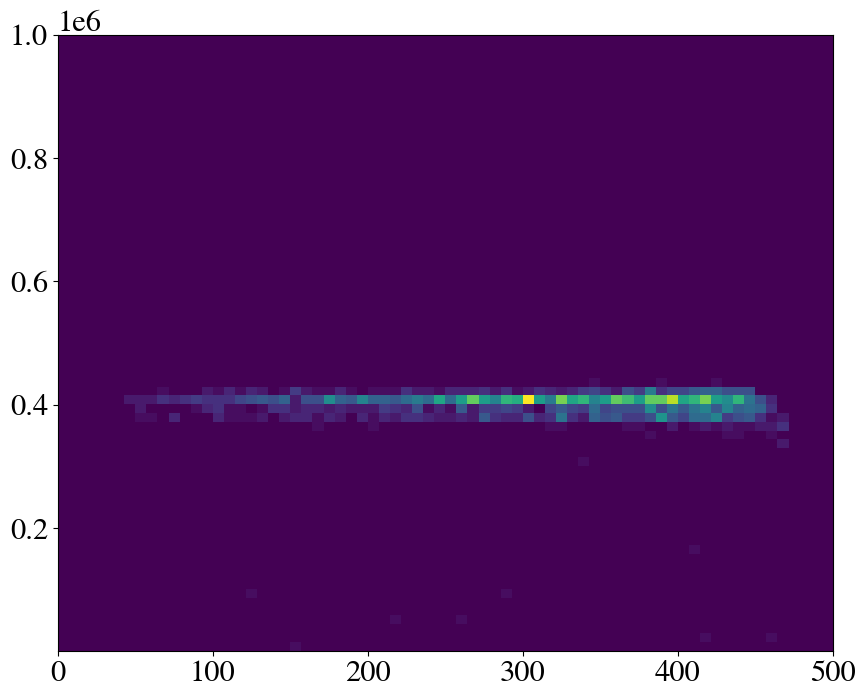

In [74]:
plt.hist2d(events.R, events.Ecccccc, range=[[0, 500], [1500, 1000000]], bins=70)
           #bins = 70)

/tmp/ipykernel_576717/2016444401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  holder_smaller['R'] = (holder_smaller['X']**2 + holder_smaller['Y']**2)**0.5


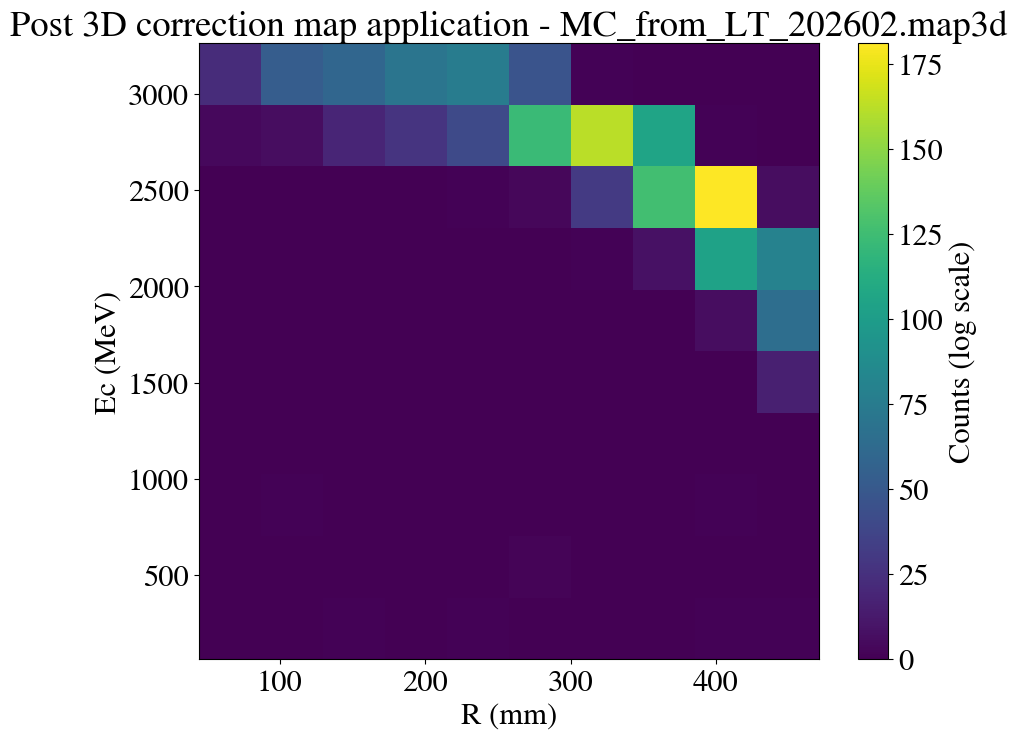

In [ ]:
plt.hist2d(holder_smaller.groupby('event').radius.mean(), holder_smaller.groupby('event').Ec_newmap.sum())
           #range=[[0, 500], [1500, 1700]], bins=70)
           #bins = 70)
plt.xlabel('R (mm)')
plt.ylabel('Ec (MeV)')
plt.title(f"Post 3D correction map application - {map3d_filename.split('/')[-1]}")
plt.colorbar(label='Counts (log scale)')
plt.show()

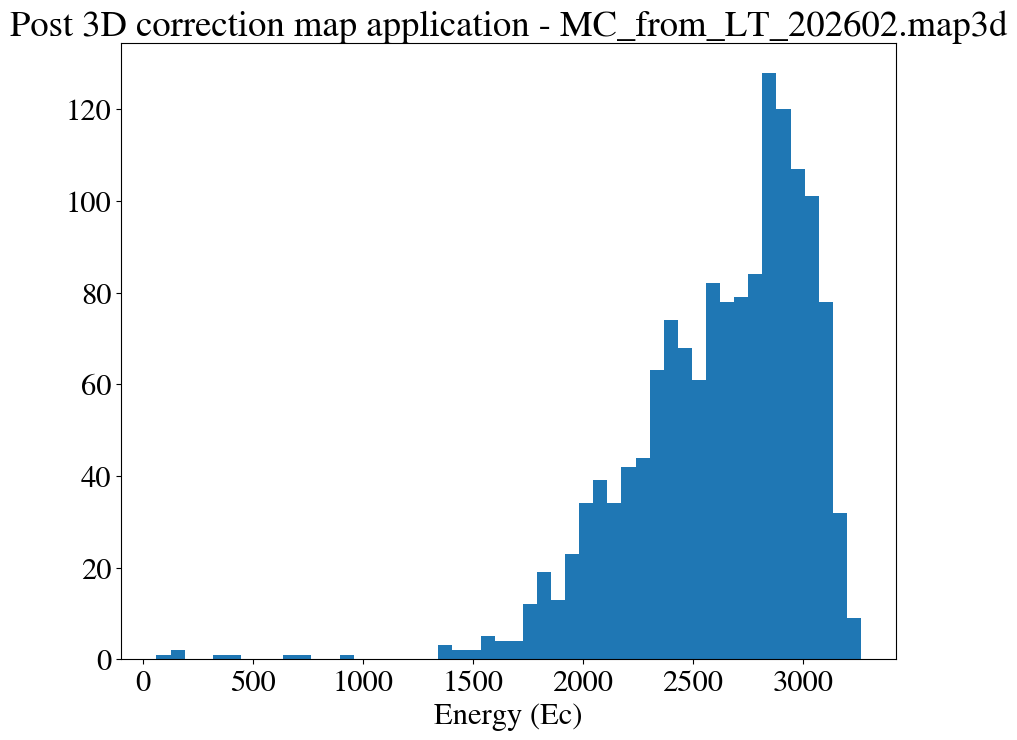

In [30]:
plt.hist(holder_smaller.groupby('event').Ec_newmap.sum(), bins = 50)#, range = (1500, 1700))
#plt.title('MC - 3D corrected')
plt.title(f"Post 3D correction map application - {map3d_filename.split('/')[-1]}")
plt.xlabel('Energy (Ec)')
plt.show()